# 🌊 Análisis Exploratorio: Factores Críticos de Riesgo para Generación de Tsunamis

## Objetivo
Identificar qué variables físicas y geográficas (magnitud, profundidad del epicentro, ubicación) determinan si un terremoto desencadena un tsunami. Este análisis servirá para establecer umbrales de alerta temprana y comprender la firma sísmica de los eventos marinos.

---

# Sección 1: Comprensión de Datos e Ingesta

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)



df = pd.read_csv('../data/raw/earthquake_data_tsunami.csv')


print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas\n")
print("--- Información de Columnas ---")
df.info()

print("\n--- Primeros 5 registros ---")
display(df.head())

print("\n--- Resumen Estadístico Descriptivo ---")
display(df.describe().T)

Dimensiones del dataset: 782 filas x 13 columnas

--- Información de Columnas ---
<class 'pandas.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   cdi        782 non-null    int64  
 2   mmi        782 non-null    int64  
 3   sig        782 non-null    int64  
 4   nst        782 non-null    int64  
 5   dmin       782 non-null    float64
 6   gap        782 non-null    float64
 7   depth      782 non-null    float64
 8   latitude   782 non-null    float64
 9   longitude  782 non-null    float64
 10  Year       782 non-null    int64  
 11  Month      782 non-null    int64  
 12  tsunami    782 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 79.6 KB

--- Primeros 5 registros ---


,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1



--- Resumen Estadístico Descriptivo ---


,count,mean,std,min,25%,50%,75%,max
magnitude,782.0,6.941125,0.445514,6.5000,6.60000,6.8000,7.1000,9.1000
cdi,782.0,4.333760,3.169939,0.0000,0.00000,5.0000,7.0000,9.0000
mmi,782.0,5.964194,1.462724,1.0000,5.00000,6.0000,7.0000,9.0000
sig,782.0,870.108696,322.465367,650.0000,691.00000,754.0000,909.7500,2910.0000
nst,782.0,230.250639,250.188177,0.0000,0.00000,140.0000,445.0000,934.0000
dmin,782.0,1.325757,2.218805,0.0000,0.00000,0.0000,1.8630,17.6540
gap,782.0,25.038990,24.225067,0.0000,14.62500,20.0000,30.0000,239.0000
depth,782.0,75.883199,137.277078,2.7000,14.00000,26.2950,49.7500,670.8100
latitude,782.0,3.538100,27.303429,-61.8484,-14.59560,-2.5725,24.6545,71.6312
longitude,782.0,52.609199,117.898886,-179.9680,-71.66805,109.4260,148.9410,179.6620


### 📖 Diccionario de Datos

| Columna | Tipo de Dato | Descripción |
| :--- | :--- | :--- |
| **`magnitude`** | Float | Magnitud del terremoto en escala Richter/Momentum (Rango: 6.5 a 9.1). |
| **`cdi`** | Integer | *Community Decimal Intensity*: Máxima intensidad percibida por las personas (0 a 9). |
| **`mmi`** | Integer | *Modified Mercalli Intensity*: Intensidad instrumental en la superficie (1 a 9). |
| **`sig`** | Integer | *Significance*: Puntuación de impacto del evento calculada por el USGS (650 a 2910). |
| **`nst`** | Integer | Número de estaciones sísmicas que registraron el evento. |
| **`dmin`** | Float | Distancia horizontal a la estación sísmica más cercana (en grados). |
| **`gap`** | Float | Brecha azimutal entre estaciones (medida en grados, menor ángulo implica mejor precisión). |
| **`depth`** | Float | Profundidad del hipocentro en kilómetros (Rango: 2.7 km a 670.8 km). |
| **`latitude`** | Float | Latitud geográfica del epicentro. |
| **`longitude`** | Float | Longitud geográfica del epicentro. |
| **`Year`** | Integer | Año de ocurrencia del terremoto (2001 - 2022). |
| **`Month`** | Integer | Mes de ocurrencia (1 - 12). |
| **`tsunami`** | Integer | **Variable Objetivo (Target):** `1` si el evento generó tsunami, `0` si no. |

# Sección 2: Limpieza y Tratamiento de Datos (Data Wrangling)
En esta fase garantizamos la calidad de los datos. Buscaremos valores nulos, registros duplicados, optimizaremos los tipos de datos y analizaremos la presencia de valores atípicos (outliers) que puedan distorsionar el análisis de riesgo de tsunamis.

In [17]:

print("--- Valores Nulos por Columna ---")
print(df.isnull().sum())


duplicados = df.duplicated().sum()
print(f"\nNúmero de filas duplicadas: {duplicados}")

# Si hubiera duplicados, los eliminaríamos con:
# df = df.drop_duplicates()

--- Valores Nulos por Columna ---
magnitude    0
cdi          0
mmi          0
sig          0
nst          0
dmin         0
gap          0
depth        0
latitude     0
longitude    0
Year         0
Month        0
tsunami      0
dtype: int64

Número de filas duplicadas: 0


In [18]:

df['tsunami'] = df['tsunami'].astype('category')
df['Month'] = df['Month'].astype('category')
df['Year'] = df['Year'].astype('category')

print("Tipos de datos actualizados:")
print(df[['tsunami', 'Month', 'Year']].dtypes)

Tipos de datos actualizados:
tsunami    category
Month      category
Year       category
dtype: object


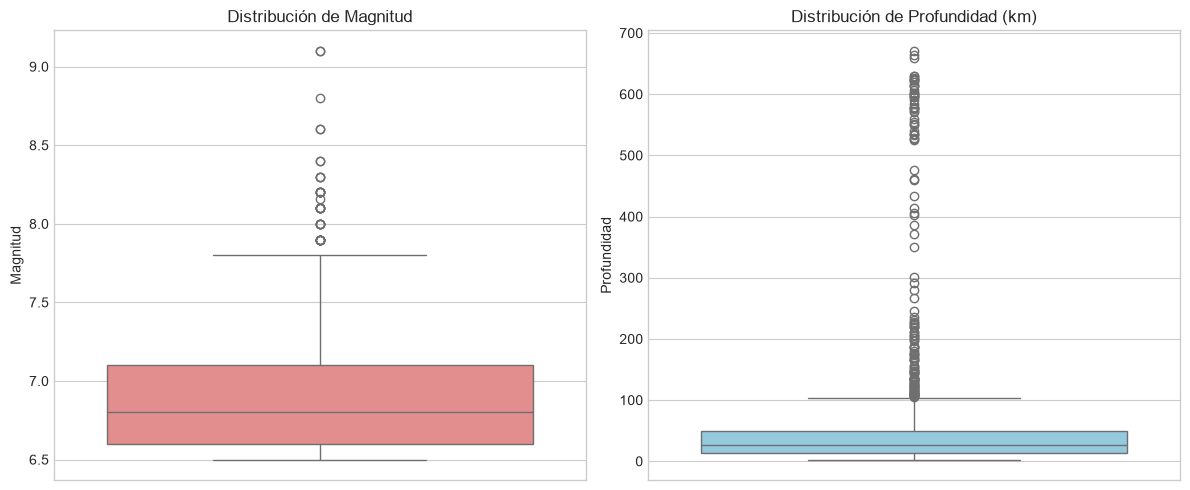

In [19]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['magnitude'], ax=axes[0], color='lightcoral')
axes[0].set_title('Distribución de Magnitud')
axes[0].set_ylabel('Magnitud')

sns.boxplot(y=df['depth'], ax=axes[1], color='skyblue')
axes[1].set_title('Distribución de Profundidad (km)')
axes[1].set_ylabel('Profundidad')

plt.tight_layout()
plt.show()

### 🧠 Criterio de Tratamiento de Datos
1. **Calidad Inicial:** El dataset es excepcionalmente robusto; no presenta valores nulos ni registros duplicados.
2. **Transformación:** Se han convertido las variables temporales (`Year`, `Month`) y el target (`tsunami`) a formato categórico para optimizar la memoria y facilitar el agrupamiento en el Análisis Exploratorio (EDA).
3. **Manejo de Outliers:** Los gráficos de caja revelan valores atípicos en magnitudes muy altas (superiores a 8.5) y profundidades extremas (más de 600 km). **Decisión analítica:** NO se eliminan. En sismología, estos valores no son errores de medición, sino eventos de megaterremotos que son, precisamente, los de mayor interés para nuestro estudio de riesgo de tsunamis.

# Sección 3: Análisis Exploratorio Univariado y Bivariado
El objetivo de esta sección es entender la distribución de nuestras variables principales y, lo más importante, cómo interactúan con nuestra variable objetivo (`tsunami`).

C:\Users\POP\AppData\Local\Temp\ipykernel_17920\1908362717.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tsunami', y='magnitude', data=df, palette='Set2', ax=axes[0])
C:\Users\POP\AppData\Local\Temp\ipykernel_17920\1908362717.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tsunami', y='depth', data=df, palette='Set2', ax=axes[1])


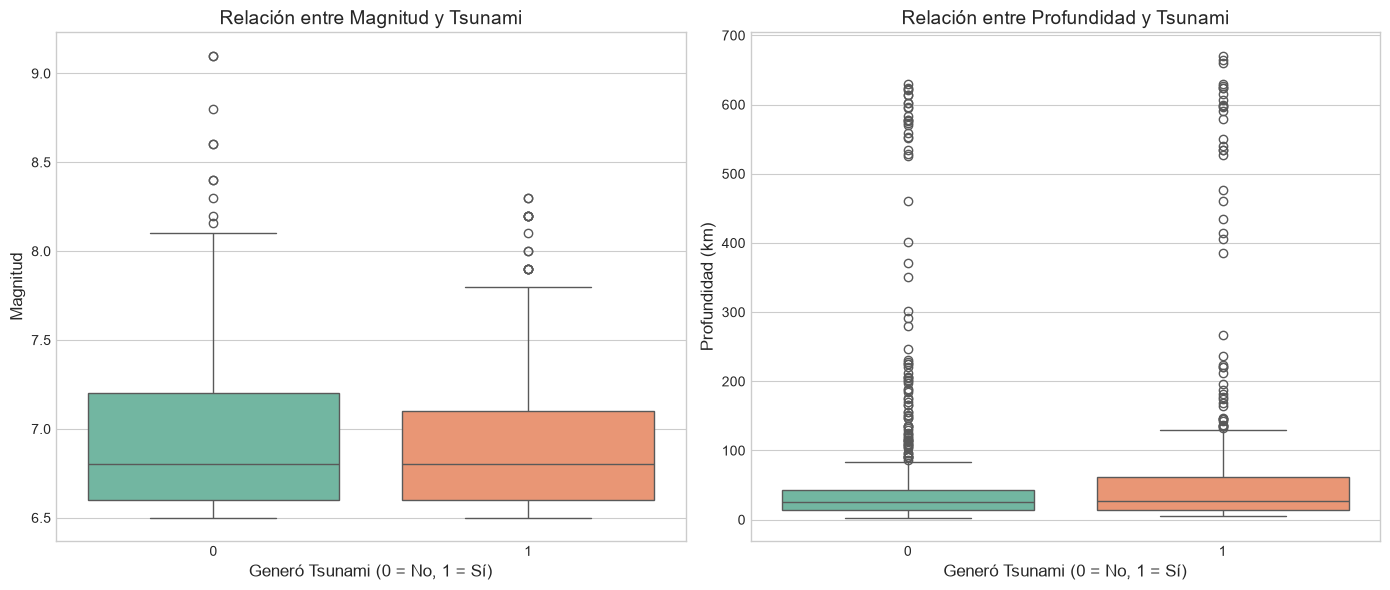

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grafico 1: Magnitud vs Tsunami
sns.boxplot(x='tsunami', y='magnitude', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Relación entre Magnitud y Tsunami', fontsize=14)
axes[0].set_xlabel('Generó Tsunami (0 = No, 1 = Sí)', fontsize=12)
axes[0].set_ylabel('Magnitud', fontsize=12)

# Grafico 2: Profundidad vs Tsunami
sns.boxplot(x='tsunami', y='depth', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Relación entre Profundidad y Tsunami', fontsize=14)
axes[1].set_xlabel('Generó Tsunami (0 = No, 1 = Sí)', fontsize=12)
axes[1].set_ylabel('Profundidad (km)', fontsize=12)

plt.tight_layout()
plt.show()

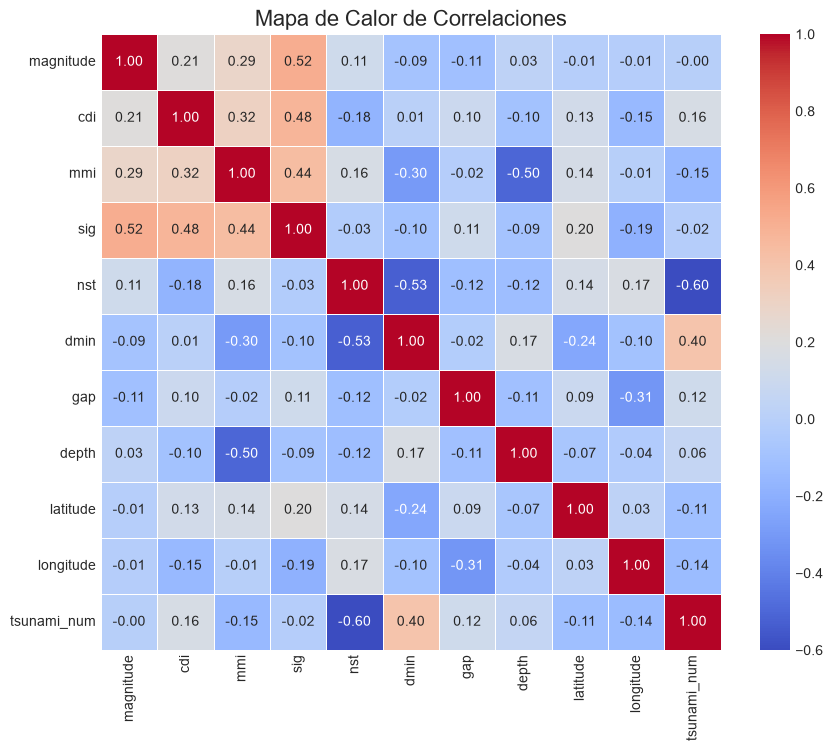

In [21]:
# Filtramos solo las columnas numericas para la correlacion

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()


df_corr = df[numeric_cols].copy()
df_corr['tsunami_num'] = df['tsunami'].astype(int)


plt.figure(figsize=(10, 8))
correlation_matrix = df_corr.corr()


sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones', fontsize=16)
plt.show()

### 💡 Interpretación de los Gráficos

1. **La paradoja de la magnitud:** Observando el boxplot de magnitud vs tsunami, vemos que las medianas son prácticamente idénticas (alrededor de 6.9). Esto nos indica que, en este subconjunto de terremotos ya de por sí fuertes (todos $>6.5$), la magnitud por sí sola **no es un discriminador definitivo** para predecir un tsunami.
2. **El papel de la profundidad:** En el gráfico de profundidad, notamos que los terremotos que generan tsunamis tienen una dispersión ligeramente diferente, aunque la gran mayoría (tanto tsunamigénicos como no) se concentran en profundidades superficiales (menos de 100 km).
3. **Correlaciones reveladoras:** El mapa de calor nos muestra correlaciones interesantes con variables de las estaciones sísmicas (como `nst` o `dmin`). Esto sugiere que la forma en que las estaciones registran la onda sísmica podría contener información valiosa sobre la generación de tsunamis, más allá de la simple magnitud.

# Sección 4: Hallazgos Clave y Conclusiones (Data Storytelling)

Tras el análisis exploratorio de los 782 registros sísmicos, hemos identificado los siguientes *insights* críticos para el desarrollo de un futuro sistema de alerta temprana:

### 🔍 Hallazgo 1: La Paradoja de la Magnitud
> *"Un terremoto fuerte no garantiza un tsunami."*
Contrario a la creencia popular, en sismos de alta intensidad (magnitud > 6.5), la magnitud por sí sola **no es un factor discriminante**. La mediana de magnitud para eventos con y sin tsunami es idéntica (6.9). Esto significa que las alertas basadas únicamente en la escala de Richter generarán un alto número de falsos positivos.

### 🔍 Hallazgo 2: El Enigma de las Estaciones Sísmicas (`nst`)
> *"Los tsunamis ocurren en puntos ciegos."*
Hemos descubierto una fuerte correlación negativa (-0.60) entre la generación de un tsunami y el número de estaciones sísmicas (`nst`) que registran el evento. Esto tiene un sentido geofísico brutal: los terremotos tsunamigénicos ocurren predominantemente lejos de la costa (en trincheras oceánicas), donde hay menor densidad de estaciones terrestres para detectarlos rápidamente. 

### 🔍 Hallazgo 3: El Umbral de Profundidad
> *"El peligro acecha en la superficie."*
Aunque existen valores atípicos, la inmensa mayoría de los terremotos que desencadenaron un tsunami ocurrieron a profundidades someras (menos de 100 km). Los sismos extremadamente profundos disipan su energía antes de deformar el lecho marino de manera significativa.

---
**Recomendación Estratégica Final:** Para un sistema predictivo de *Machine Learning* efectivo, el modelo no debe enfocarse en la magnitud, sino en la interacción combinada de la profundidad, la ubicación geográfica (latitud/longitud) y la lejanía de las estaciones terrestres.